# HW10-11

### Петров Александр ИКБО-40-24

**Выбранный датасет: Flowers102**

## 0. Импортированные модули, воспроизводимость, устройство, пути и константы

In [1]:
import json
import math
import time
import random
from typing import Dict, List
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from torchvision.datasets import Flowers102, VOCDetection
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn

from torchvision import transforms

In [ ]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def get_resnet18_weights():
    try:
        w = ResNet18_Weights.DEFAULT
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None


def build_resnet18(weights, num_classes: int = 10) -> nn.Module:
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

In [3]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    
    print(f"Seed set to: {seed}")


SEED = 42
set_seed(SEED)

Seed set to: 42


In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [5]:
ARTIFACTS_DIR = Path("./artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

DATA_DIR = "./data"
BATCH_SIZE = 64
EPOCHS = 10
NUM_CLASSES = 102

FLOWERS102_MEAN = [0.485, 0.456, 0.406]
FLOWERS102_STD = [0.229, 0.224, 0.225]

print(f"Artifacts dir: {ARTIFACTS_DIR.absolute()}")
print(f"Figures dir: {FIGURES_DIR.absolute()}")

Artifacts dir: /content/artifacts
Figures dir: /content/artifacts/figures


## 1. Загрузка данных

In [ ]:
transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=FLOWERS102_MEAN,
            std=FLOWERS102_STD
        )
    ]
)

transform_aug = transforms.Compose(
    [
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=FLOWERS102_MEAN,
            std=FLOWERS102_STD
        )
    ]
)

In [7]:
def load_flowers102(train_transform, data_dir: str = DATA_DIR):
    ds_train = Flowers102(
        root=data_dir,
        split="train",
        download=True,
        transform=train_transform
    )
    ds_val = Flowers102(
        root=data_dir,
        split="val",
        download=True,
        transform=transform
    )
    ds_test = Flowers102(
        root=data_dir,
        split="test",
        download=True,
        transform=transform
    )

    return ds_train, ds_val, ds_test


ds_train, ds_val, ds_test = load_flowers102(train_transform=transform)
class_names = ds_train.classes
print("Train:", len(ds_train))
print("Val:", len(ds_val))
print("Test:", len(ds_test), end="\n\n")

print("Classes:", class_names)
print("Total classes:", len(class_names))

100%|██████████| 345M/345M [00:15<00:00, 21.6MB/s] 
100%|██████████| 502/502 [00:00<00:00, 1.99MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 40.8MB/s]


Train: 1020
Val: 1020
Test: 6149

Classes: ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower', 'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 'carnation', 'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 

In [8]:
def make_loaders(
    ds_train,
    ds_val,
    ds_test,
    batch_size: int = BATCH_SIZE
):
    train_loader = DataLoader(
        ds_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )
    val_loader = DataLoader(
        ds_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )
    test_loader = DataLoader(
        ds_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(
    ds_train,
    ds_val, 
    ds_test
)

batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


### Визуализация

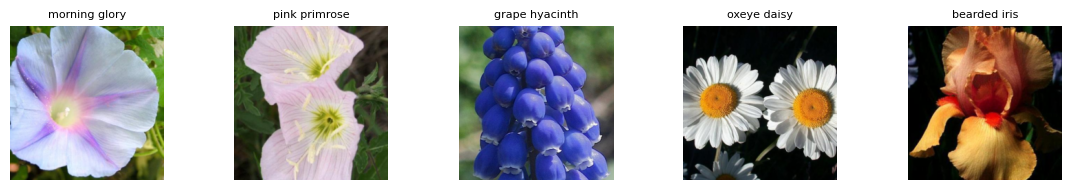

In [9]:
def denorm_flowers102(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(FLOWERS102_MEAN).view(3, 1, 1)
    std = torch.tensor(FLOWERS102_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_flowers102(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()


show_images(train_loader, n=5)

Визуализация аугментаций.

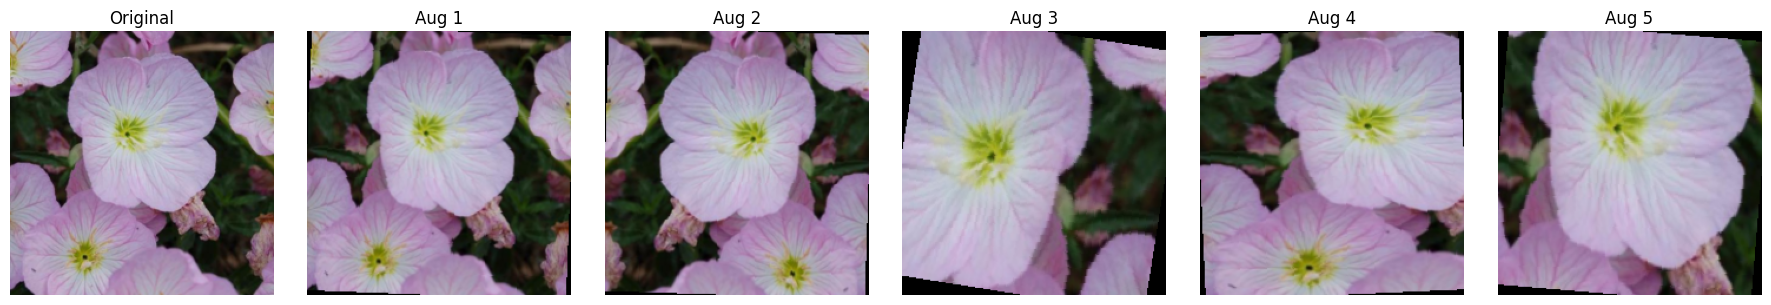

Сохранено: artifacts/figures/augmentations_preview.png


In [10]:
def visualize_augmentations(original_img: torch.Tensor, aug_transform, n: int = 8) -> None:
    mean = torch.tensor(FLOWERS102_MEAN).view(3, 1, 1)
    std  = torch.tensor(FLOWERS102_STD).view(3, 1, 1)

    def to_display(t: torch.Tensor):
        return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    pil_img = transforms.ToPILImage()(
        (original_img * std + mean).clamp(0, 1)
    )

    fig, axes = plt.subplots(1, n + 1, figsize=(3 * (n + 1), 3))

    # Оригинал
    axes[0].imshow(to_display(original_img))
    axes[0].set_title("Original")
    axes[0].axis("off")

    # Аугментированные версии
    for i in range(n):
        augmented = aug_transform(pil_img)
        axes[i + 1].imshow(to_display(augmented))
        axes[i + 1].set_title(f"Aug {i + 1}")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "augmentations_preview.png", bbox_inches="tight")
    plt.show()
    
    print("Сохранено: artifacts/figures/augmentations_preview.png")

sample_img, _ = ds_train[0]
visualize_augmentations(sample_img, transform_aug, n=5)

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 224x224
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> 112x112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 112x112
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> 56x56

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 56x56
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 28x28
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn = SimpleCNN(NUM_CLASSES).to(device)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=102, bias=True)
  )
)
Trainable params: 25809830


In [12]:
# Sanity-check
with torch.no_grad():
    x0 = torch.randn(2, 3, 224, 224).to(device)
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 224, 224]) Output logits: torch.Size([2, 102])


In [ ]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

In [14]:
def fit(
    model,
    train_loader, val_loader,
    optimizer, criterion, epochs: int, 
    device, verbose: bool = True
):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(f"Epoch {epoch:02d}/{epochs} | train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                  f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s")

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    return history

In [ ]:
def plot_history(hist: Dict[str, List[float]], title: str = "", save_path: str = None) -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(epochs, hist["train_loss"], label="train loss")
    axes[0].plot(epochs, hist["val_loss"], label="val loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].set_title(title + " | loss")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(epochs, hist["train_acc"], label="train acc")
    axes[1].plot(epochs, hist["val_acc"], label="val acc")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_title(title + " | accuracy")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Сохранено: {save_path}")
    plt.show()

## Часть А

### C1

In [ ]:
# Контейнер для результатов
results = []
criterion = nn.CrossEntropyLoss()

def run_experiment(exp_id: str, model: nn.Module, train_loader, val_loader,
                   lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = EPOCHS):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs, device, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    results.append({
        "experiment_id": exp_id,
        "task": "classification",
        "dataset": "Flowers102",
        "seed": SEED,
        "model_summary": str(type(model).__name__),
        "optimizer": "Adam",
        "lr": lr,
        "epochs_trained": len(hist["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "test_accuracy": None,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": ""
    })

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}


Experiment C1 | lr=0.001 weight_decay=0.0 epochs=10
Trainable params: 25809830
Epoch 01/10 | train loss 5.0206, acc 0.014 | val loss 4.5786, acc 0.024 | 12.3s
Epoch 02/10 | train loss 4.4231, acc 0.031 | val loss 4.2587, acc 0.049 | 12.3s
Epoch 03/10 | train loss 3.8166, acc 0.132 | val loss 3.8220, acc 0.123 | 12.4s
Epoch 04/10 | train loss 2.9311, acc 0.283 | val loss 3.9180, acc 0.148 | 12.1s
Epoch 05/10 | train loss 2.0198, acc 0.496 | val loss 4.2996, acc 0.164 | 12.2s
Epoch 06/10 | train loss 1.2662, acc 0.672 | val loss 4.5527, acc 0.182 | 12.0s
Epoch 07/10 | train loss 0.6180, acc 0.827 | val loss 5.3739, acc 0.163 | 11.2s
Epoch 08/10 | train loss 0.2910, acc 0.922 | val loss 5.9662, acc 0.169 | 11.9s
Epoch 09/10 | train loss 0.1498, acc 0.961 | val loss 6.3108, acc 0.164 | 12.2s
Epoch 10/10 | train loss 0.0926, acc 0.976 | val loss 6.1318, acc 0.184 | 12.1s
Сохранено: artifacts/figures/c1_history.png


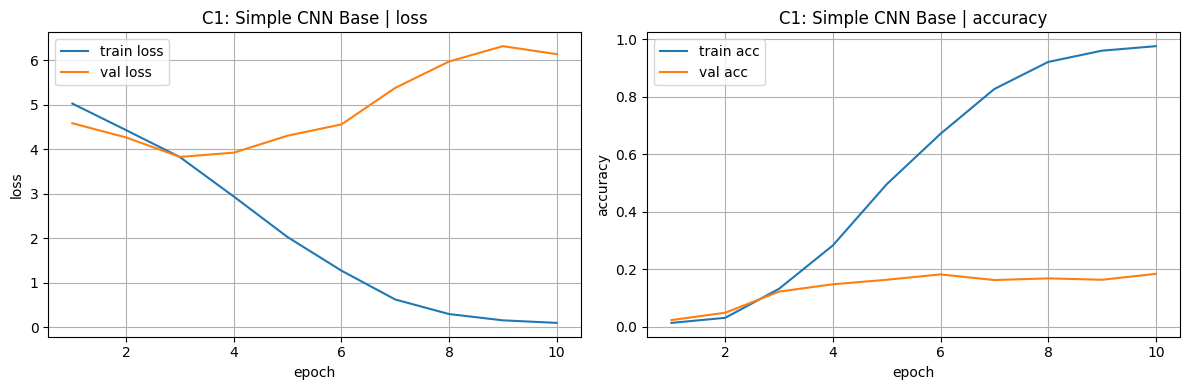

In [17]:
C1_experiment = run_experiment("C1", SimpleCNN(NUM_CLASSES), train_loader, val_loader, lr=1e-3, epochs=EPOCHS)
plot_history(C1_experiment["history"], title="C1: Simple CNN Base", save_path=str(FIGURES_DIR / "c1_history.png"))

### C2

Заново загрузим данные, теперь уже с дополнительными аугментациями.


Experiment C2 | lr=0.001 weight_decay=0.0 epochs=10
Trainable params: 25809830
Epoch 01/10 | train loss 5.1978, acc 0.004 | val loss 4.6256, acc 0.010 | 11.7s
Epoch 02/10 | train loss 4.6259, acc 0.006 | val loss 4.6257, acc 0.010 | 11.5s
Epoch 03/10 | train loss 4.6259, acc 0.010 | val loss 4.6256, acc 0.010 | 11.7s
Epoch 04/10 | train loss 4.6259, acc 0.010 | val loss 4.6256, acc 0.010 | 11.6s
Epoch 05/10 | train loss 4.6259, acc 0.008 | val loss 4.6256, acc 0.010 | 11.7s
Epoch 06/10 | train loss 4.6259, acc 0.006 | val loss 4.6256, acc 0.010 | 11.6s
Epoch 07/10 | train loss 4.6258, acc 0.010 | val loss 4.6256, acc 0.010 | 11.4s
Epoch 08/10 | train loss 4.6258, acc 0.008 | val loss 4.6255, acc 0.010 | 11.0s
Epoch 09/10 | train loss 4.6258, acc 0.009 | val loss 4.6255, acc 0.010 | 11.4s
Epoch 10/10 | train loss 4.6258, acc 0.010 | val loss 4.6255, acc 0.010 | 11.8s
Сохранено: artifacts/figures/c2_history.png


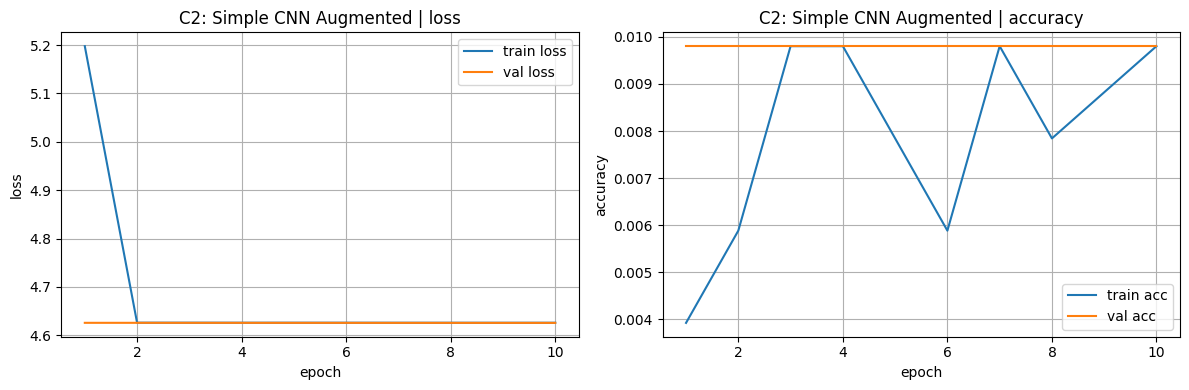

In [18]:
ds_train_aug, _, _ = load_flowers102(train_transform=transform_aug)
train_loader_aug, _, _ = make_loaders(ds_train_aug, ds_val, ds_test)

C2_experiment = run_experiment("C2", SimpleCNN(NUM_CLASSES), train_loader_aug, val_loader, lr=1e-3, epochs=EPOCHS)
plot_history(C2_experiment["history"], title="C2: Simple CNN Augmented", save_path=str(FIGURES_DIR / "c2_history.png"))

На таком маленьком датасете как Flowers102 (всего по 10 обучающих изображений на класс) аугментации только помешали.

### C3

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


Trainable params (head-only): 52326

Experiment C3 | lr=0.001 weight_decay=0.0 epochs=10
Trainable params: 52326
Epoch 01/10 | train loss 4.6717, acc 0.037 | val loss 4.0960, acc 0.139 | 12.0s
Epoch 02/10 | train loss 3.6266, acc 0.299 | val loss 3.3787, acc 0.439 | 11.7s
Epoch 03/10 | train loss 2.7987, acc 0.654 | val loss 2.7922, acc 0.605 | 11.9s
Epoch 04/10 | train loss 2.1418, acc 0.843 | val loss 2.3434, acc 0.698 | 11.6s
Epoch 05/10 | train loss 1.6491, acc 0.913 | val loss 1.9883, acc 0.755 | 11.8s
Epoch 06/10 | train loss 1.2625, acc 0.953 | val loss 1.7289, acc 0.786 | 11.7s
Epoch 07/10 | train loss 0.9994, acc 0.969 | val loss 1.5371, acc 0.806 | 11.7s
Epoch 08/10 | train loss 0.8053, acc 0.981 | val loss 1.4072, acc 0.824 | 11.3s
Epoch 09/10 | train loss 0.6544, acc 0.977 | val loss 1.2870, acc 0.821 | 10.7s
Epoch 10/10 | train loss 0.5496, acc 0.989 | val loss 1.2107, acc 0.832 | 11.6s
Сохранено: artifacts/figures/c3_history.png


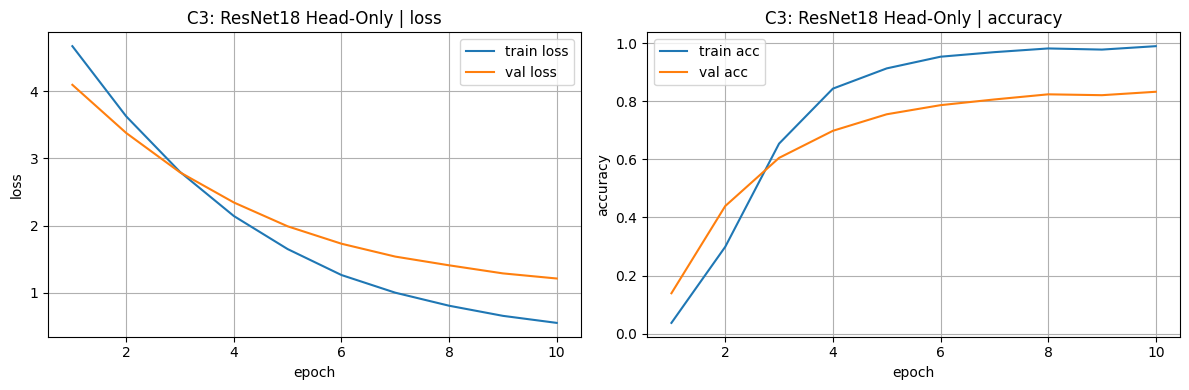

In [19]:
weights = get_resnet18_weights()
model_head = build_resnet18(num_classes=NUM_CLASSES, weights=weights).to(device)

set_requires_grad(model_head, False)
set_requires_grad(model_head.fc, True)

print(f"Trainable params (head-only): {count_params(model_head)}")

C3_experiment = run_experiment("C3", model_head, train_loader, val_loader, lr=1e-3, epochs=EPOCHS)
plot_history(C3_experiment["history"], title="C3: ResNet18 Head-Only", save_path=str(FIGURES_DIR / "c3_history.png"))

### C4

Trainable params (finetune): 8446054

Experiment C4 | lr=0.0001 weight_decay=0.0 epochs=10
Trainable params: 8446054
Epoch 01/10 | train loss 4.4320, acc 0.070 | val loss 3.8489, acc 0.244 | 11.9s
Epoch 02/10 | train loss 2.9058, acc 0.655 | val loss 3.0150, acc 0.558 | 11.7s
Epoch 03/10 | train loss 1.9630, acc 0.931 | val loss 2.4525, acc 0.702 | 11.7s
Epoch 04/10 | train loss 1.3060, acc 0.986 | val loss 2.0688, acc 0.772 | 11.6s
Epoch 05/10 | train loss 0.8592, acc 0.996 | val loss 1.8242, acc 0.825 | 11.6s
Epoch 06/10 | train loss 0.5529, acc 1.000 | val loss 1.6759, acc 0.850 | 11.9s
Epoch 07/10 | train loss 0.3696, acc 1.000 | val loss 1.5232, acc 0.869 | 11.6s
Epoch 08/10 | train loss 0.2531, acc 1.000 | val loss 1.4363, acc 0.874 | 11.3s
Epoch 09/10 | train loss 0.1804, acc 1.000 | val loss 1.3454, acc 0.877 | 10.8s
Epoch 10/10 | train loss 0.1413, acc 1.000 | val loss 1.2878, acc 0.882 | 11.7s
Сохранено: artifacts/figures/c4_history.png


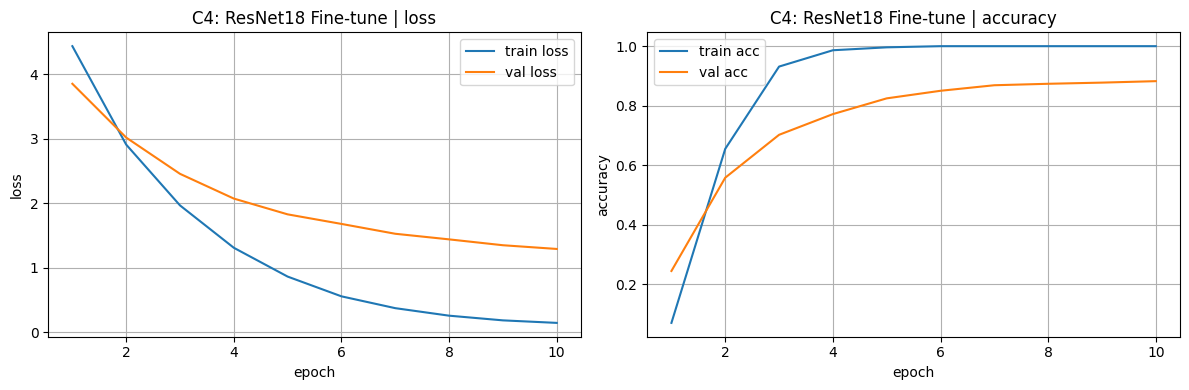

In [20]:
model_finetune = build_resnet18(num_classes=NUM_CLASSES, weights=weights).to(device)

# Замораживаем всё, кроме layer4 и fc
set_requires_grad(model_finetune, False)
set_requires_grad(model_finetune.layer4, True)
set_requires_grad(model_finetune.fc, True)

print(f"Trainable params (finetune): {count_params(model_finetune)}")

C4_experiment = run_experiment("C4", model_finetune, train_loader, val_loader, lr=1e-4, epochs=EPOCHS)
plot_history(C4_experiment["history"], title="C4: ResNet18 Fine-tune",
             save_path=str(FIGURES_DIR / "c4_history.png"))

Partial fine-tuning дал быструю сходимость. Стоит отметить, что accuracy на обучающей выборке - 1.0 для 5 последних эпох.

## Оценка на test

In [21]:
experiments = {
    "C1": C1_experiment,
    "C2": C2_experiment,
    "C3": C3_experiment,
    "C4": C4_experiment
}

best_exp_id = max(experiments.keys(), key=lambda k: experiments[k]["best_val_acc"])
best_experiment = experiments[best_exp_id]
best_model = best_experiment["model"]

print(f"\nЛучшая модель: {best_exp_id} | Val Accuracy: {best_experiment["best_val_acc"]:.4f}")

# Финальная оценка на test
test_loss, test_accuracy = evaluate(best_model, test_loader, criterion, device)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Обновляем результаты для лучшей модели
for r in results:
    if r["experiment_id"] == best_exp_id:
        r["test_accuracy"] = test_accuracy
        r["notes"] = "Best model"


Лучшая модель: C4 | Val Accuracy: 0.8824
Test Accuracy: 0.8523


In [22]:
# Обновляем результаты для лучшей модели
for r in results:
    if r["experiment_id"] == best_exp_id:
        r["test_accuracy"] = test_accuracy
        r["notes"] = "Best model"

# Сохраняем лучшую модель
torch.save(best_model.state_dict(), ARTIFACTS_DIR / "best_classifier.pt")
print(f"Сохранено: artifacts/best_classifier.pt")

# Сохраняем конфиг лучшей модели
config = {
    "dataset": "Flowers102",
    "architecture": type(best_model).__name__,
    "num_classes": NUM_CLASSES,
    "transforms": {
        "train": "transform_aug" if best_exp_id == "C2" else "transform_base",
        "val": "transform_base",
        "test": "transform_base"
    },
    "hyperparameters": {
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "lr": 1e-3 if best_exp_id in ["C1", "C2", "C3"] else 1e-4,
        "optimizer": "Adam",
        "criterion": "CrossEntropyLoss"
    },
    "seed": SEED,
    "device": str(device),
    "best_val_accuracy": best_experiment["best_val_acc"],
    "test_accuracy": test_accuracy
}

with open(ARTIFACTS_DIR / "best_classifier_config.json", "w") as f:
    json.dump(config, f, indent=2)
print(f"Сохранено: artifacts/best_classifier_config.json")

Сохранено: artifacts/best_classifier.pt
Сохранено: artifacts/best_classifier_config.json


Сохранено: artifacts/figures/classification_curves_best.png


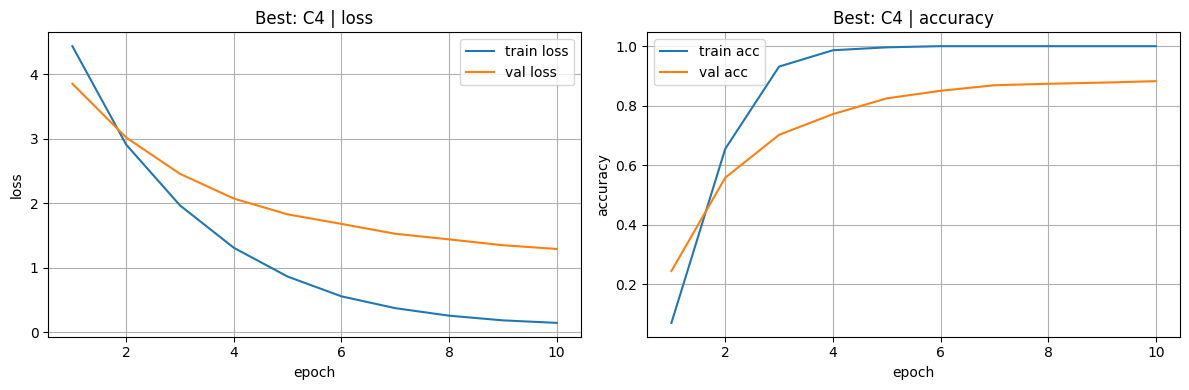

In [23]:
# График кривых лучшей модели
plot_history(
    best_experiment["history"], 
    title=f"Best: {best_exp_id}",
    save_path=str(FIGURES_DIR / "classification_curves_best.png")
)

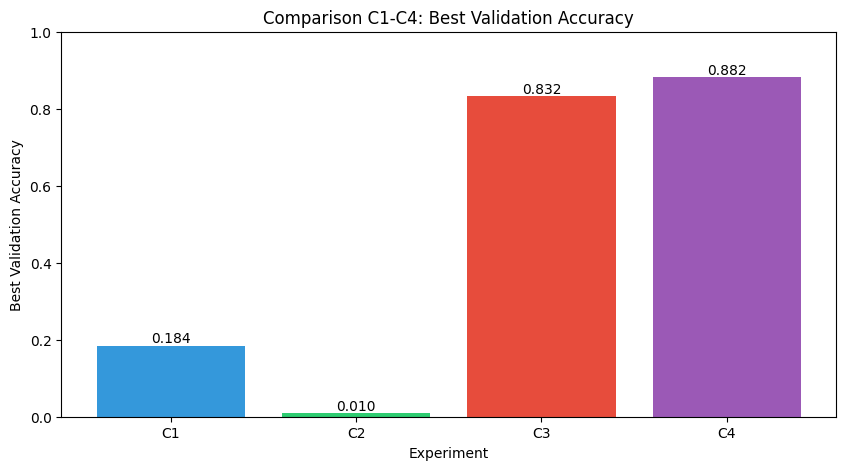

Сохранено: artifacts/figures/classification_compare.png


In [24]:
# Сравнение C1-C4 (bar plot)
exp_ids = ["C1", "C2", "C3", "C4"]
val_accs = [experiments[e]["best_val_acc"] for e in exp_ids]

plt.figure(figsize=(10, 5))
bars = plt.bar(exp_ids, val_accs, color=["#3498db", "#2ecc71", "#e74c3c", "#9b59b6"])
plt.xlabel("Experiment")
plt.ylabel("Best Validation Accuracy")
plt.title("Comparison C1-C4: Best Validation Accuracy")
plt.ylim(0, 1)

for bar, acc in zip(bars, val_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{acc:.3f}", ha="center", va="bottom", fontsize=10)

plt.savefig(FIGURES_DIR / "classification_compare.png")
plt.show()

print(f"Сохранено: artifacts/figures/classification_compare.png")

## Часть B

In [25]:
def run_detection_inference(model, image_tensor, score_threshold=0.3):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        predictions = model([image_tensor])
    
    # Фильтрация по порогу
    boxes = predictions[0]["boxes"]
    scores = predictions[0]["scores"]
    labels = predictions[0]["labels"]
    
    mask = scores >= score_threshold
    boxes = boxes[mask]
    scores = scores[mask]
    labels = labels[mask]
    
    return boxes, scores, labels


def visualize_detection(image, boxes, scores, labels, class_names=None):
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(image.permute(1, 2, 0).cpu().numpy())
    
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    
    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        x1, y1, x2, y2 = box.cpu().numpy()
        color = colors[label % 10]
        
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, 
                            color=color, linewidth=2, label=f"{label}: {score:.2f}")
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"{score:.2f}", fontsize=8, 
               bbox=dict(facecolor=color, alpha=0.7))
    
    ax.axis("off")
    plt.tight_layout()
    return fig


def parse_voc_boxes(target: dict) -> torch.Tensor:
    objs = target["annotation"]["object"]
    if isinstance(objs, dict):
        objs = [objs]
    boxes = []
    for obj in objs:
        bb = obj["bndbox"]
        boxes.append([
            float(bb["xmin"]), float(bb["ymin"]),
            float(bb["xmax"]), float(bb["ymax"])
        ])
    return torch.tensor(boxes, dtype=torch.float32)


def compute_iou(box_a: torch.Tensor, box_b: torch.Tensor) -> float:
    x1 = max(box_a[0], box_b[0]); y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2]); y2 = min(box_a[3], box_b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (box_a[2]-box_a[0]) * (box_a[3]-box_a[1])
    area_b = (box_b[2]-box_b[0]) * (box_b[3]-box_b[1])
    union = area_a + area_b - inter
    return (inter / union).item() if union > 0 else 0.0


def compute_detection_metrics(
    pred_boxes: torch.Tensor,
    gt_boxes: torch.Tensor,
    iou_threshold: float = 0.5
):
    if len(pred_boxes) == 0:
        return 0.0, 0.0, 0.0
    if len(gt_boxes) == 0:
        return 0.0, 0.0, 0.0

    matched_ious = []
    gt_matched = [False] * len(gt_boxes)

    for pred in pred_boxes:
        best_iou, best_j = 0.0, -1
        for j, gt in enumerate(gt_boxes):
            if gt_matched[j]:
                continue
            iou = compute_iou(pred, gt)
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_iou >= iou_threshold and best_j >= 0:
            matched_ious.append(best_iou)
            gt_matched[best_j] = True

    tp = len(matched_ious)
    precision  = tp / len(pred_boxes)
    recall     = tp / len(gt_boxes)
    mean_iou   = float(np.mean(matched_ious)) if matched_ious else 0.0
    return precision, recall, mean_iou


def evaluate_detection_on_dataset(model, dataset, score_threshold: float, n_images: int = 50):
    precisions, recalls, ious = [], [], []

    for idx in range(min(n_images, len(dataset))):
        image, target = dataset[idx]
        gt_boxes = parse_voc_boxes(target)

        pred_boxes, pred_scores, pred_labels = run_detection_inference(
            model, image, score_threshold=score_threshold
        )

        p, r, iou = compute_detection_metrics(pred_boxes.cpu(), gt_boxes)
        precisions.append(p)
        recalls.append(r)
        ious.append(iou)

    return {
        "precision": float(np.mean(precisions)),
        "recall":    float(np.mean(recalls)),
        "mean_iou":  float(np.mean(ious)),
    }

In [26]:
try:
    voc_detection = VOCDetection(
        root="./data_voc", year="2007", image_set="val",
        download=True,
        transform=transforms.Compose([transforms.ToTensor()])
    )
    print(f"VOCDetection loaded: {len(voc_detection)} images")
except Exception as e:
    print(f"Ошибка загрузки VOCDetection: {e}")
    voc_detection = None

detection_model = fasterrcnn_resnet50_fpn(weights="DEFAULT", box_score_thresh=0.05)
detection_model = detection_model.to(device)
detection_model.eval()

100%|██████████| 460M/460M [00:20<00:00, 22.1MB/s] 


VOCDetection loaded: 2510 images
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 177MB/s] 


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [27]:
N_EVAL = 20
detection_results = []

for exp_id, threshold in [("V1", 0.3), ("V2", 0.7)]:
    if voc_detection is None:
        break
    print(f"\nОцениваем {exp_id} (threshold={threshold}) на {N_EVAL} изображениях...")
    metrics = evaluate_detection_on_dataset(
        detection_model, voc_detection, score_threshold=threshold, n_images=N_EVAL
    )
    print(f"  precision={metrics['precision']:.3f}  "
          f"recall={metrics['recall']:.3f}  "
          f"mean_iou={metrics['mean_iou']:.3f}")
    detection_results.append({
        "experiment_id": exp_id,
        "task": "detection",
        "dataset": "PascalVOC2007",
        "seed": SEED,
        "model_summary": "FasterRCNN_ResNet50_FPN",
        "optimizer": "N/A", "lr": 0, "epochs_trained": 0,
        "best_val_accuracy": None, "test_accuracy": None,
        **metrics,
        "notes": f"score_threshold={threshold}, n_eval={N_EVAL}"
    })


Оцениваем V1 (threshold=0.3) на 20 изображениях...
  precision=0.409  recall=0.939  mean_iou=0.814

Оцениваем V2 (threshold=0.7) на 20 изображениях...
  precision=0.664  recall=0.865  mean_iou=0.777


При более низком thershold выше recall, но меньше precision. При более высоком thershold, выше precision, но меньше recall.

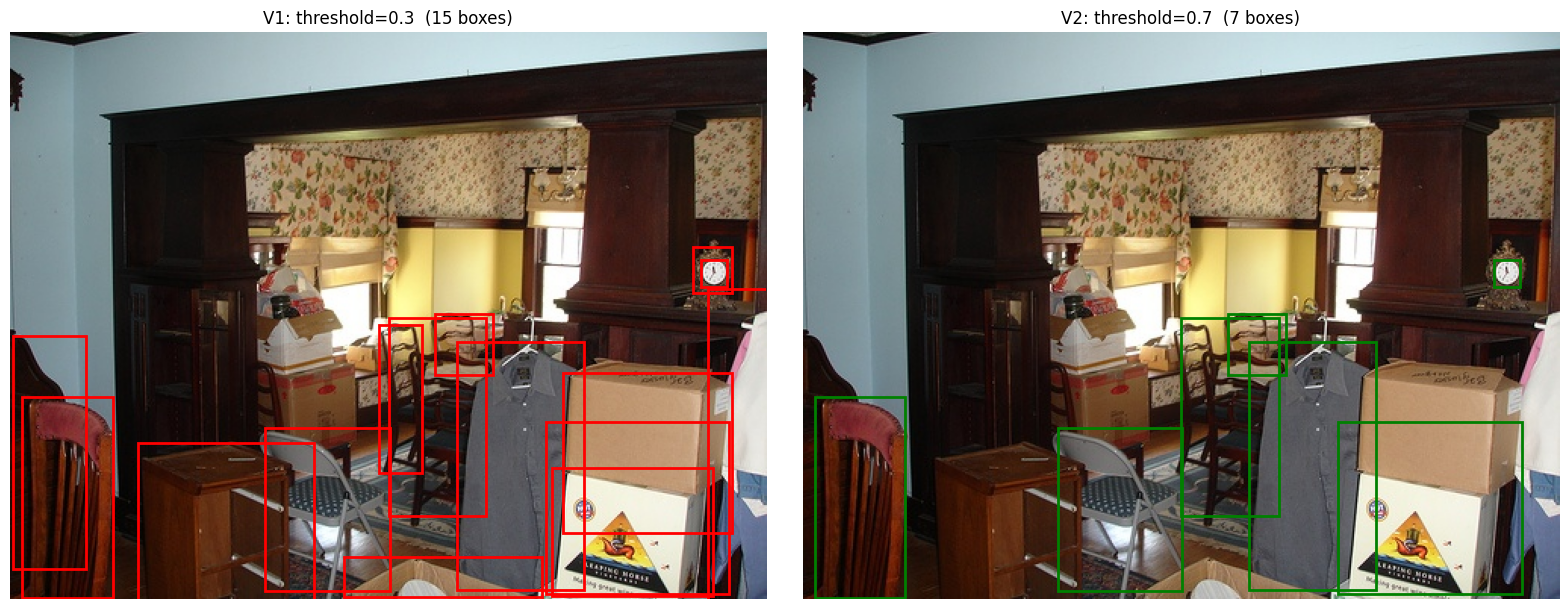

Сохранено: artifacts/figures/detection_examples.png


In [28]:
if voc_detection is not None:
    vis_image, vis_target = voc_detection[0]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, (exp_id, threshold, color) in zip(
        axes, [("V1", 0.3, "red"), ("V2", 0.7, "green")]
    ):
        boxes, scores, labels = run_detection_inference(
            detection_model, vis_image, score_threshold=threshold
        )
        ax.imshow(vis_image.permute(1, 2, 0).cpu().numpy())
        for box in boxes:
            x1, y1, x2, y2 = box.cpu().numpy()
            ax.add_patch(plt.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                fill=False, color=color, linewidth=2
            ))
        ax.set_title(f"{exp_id}: threshold={threshold}  ({len(boxes)} boxes)")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "detection_examples.png", dpi=150)
    plt.show()
    print("Сохранено: artifacts/figures/detection_examples.png")

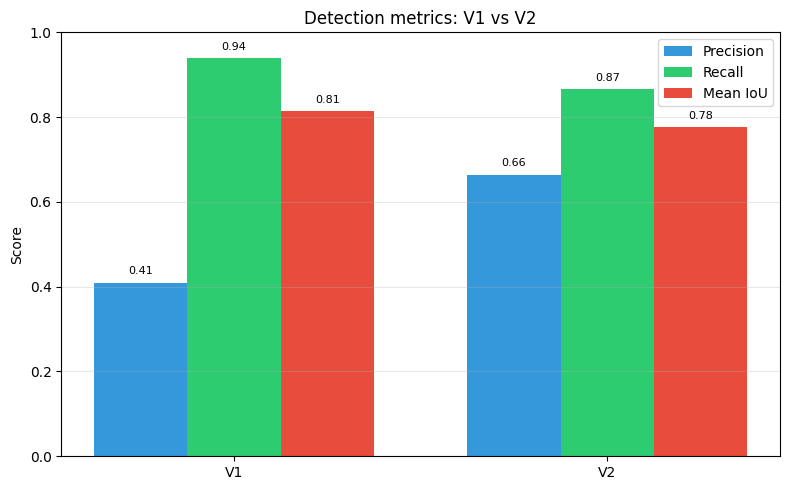

Сохранено: artifacts/figures/detection_metrics.png


In [29]:
if detection_results:
    exp_ids_det = [r["experiment_id"] for r in detection_results]
    precisions  = [r["precision"]     for r in detection_results]
    recalls     = [r["recall"]        for r in detection_results]
    mean_ious   = [r["mean_iou"]      for r in detection_results]

    x = np.arange(len(exp_ids_det))
    width = 0.25

    plt.figure(figsize=(8, 5))
    plt.bar(x - width, precisions, width, label="Precision",  color="#3498db")
    plt.bar(x,         recalls,    width, label="Recall",     color="#2ecc71")
    plt.bar(x + width, mean_ious,  width, label="Mean IoU",   color="#e74c3c")
    plt.xticks(x, exp_ids_det)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title("Detection metrics: V1 vs V2")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    for i, (p, r, iou) in enumerate(zip(precisions, recalls, mean_ious)):
        plt.text(i - width, p + 0.02, f"{p:.2f}", ha="center", fontsize=8)
        plt.text(i,         r + 0.02, f"{r:.2f}", ha="center", fontsize=8)
        plt.text(i + width, iou+0.02, f"{iou:.2f}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "detection_metrics.png", dpi=150)
    plt.show()
    print("Сохранено: artifacts/figures/detection_metrics.png")

In [30]:
all_results = results + detection_results
df_results = pd.DataFrame(all_results)
df_results.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
print(f"\nСохранено: artifacts/runs.csv")
print(df_results.to_string())


Сохранено: artifacts/runs.csv
  experiment_id            task        dataset  seed            model_summary optimizer      lr  epochs_trained  best_val_accuracy  test_accuracy  precision    recall  mean_iou                           notes
0            C1  classification     Flowers102    42                SimpleCNN      Adam  0.0010              10           0.184314            NaN        NaN       NaN       NaN                                
1            C2  classification     Flowers102    42                SimpleCNN      Adam  0.0010              10           0.009804            NaN        NaN       NaN       NaN                                
2            C3  classification     Flowers102    42                   ResNet      Adam  0.0010              10           0.832353            NaN        NaN       NaN       NaN                                
3            C4  classification     Flowers102    42                   ResNet      Adam  0.0001              10           0.882353   